# Bootstrap Analysis for Self-Prioritization Effect (v4.3)

**Definition**:
- **Strict approach** = Aligned version (Shape和Label样本量对齐)
- **Loose approach** = Max version (各自取最大样本量)

**Output**: 1 combined figure (2x2 layout)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set APA style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load data
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap/v4_legend_optimized")

clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

all_data = []
for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
    except Exception as e:
        print(f"Error: {file_path.name}: {e}")

merged_df = pd.concat(all_data, ignore_index=True)

# Check Label column
if 'Label_Standardized_Identity' not in merged_df.columns:
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

# Filter Nonmatching
mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)}, Participants: {mismatch_df['Subject'].nunique()}")

Found 72 Clean.csv files
Mismatch trials: 853015, Participants: 1676


In [3]:
# Helper functions
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (mean1 - mean2) / pooled_sd if pooled_sd != 0 else np.nan

def filter_valid_subjects(df, identity_column):
    valid = []
    for subject, subj_df in df.groupby('Subject'):
        ids = set(subj_df[identity_column].dropna().unique())
        if 'Self' in ids and 'Stranger' in ids and len(ids) >= 3:
            valid.append(subject)
    return valid

print("Helper functions defined!")

Helper functions defined!


In [4]:
# Data processing functions
def process_data_strict(df, analysis_type='Shape'):
    """Strict filtering: exclude Primary=Stranger & Secondary=Self"""
    if analysis_type == 'Shape':
        primary_col = 'Shape_Standardized_Identity'
        secondary_col = 'Label_Standardized_Identity'
    else:
        primary_col = 'Label_Standardized_Identity'
        secondary_col = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, primary_col)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    
    df_filtered['Primary'] = df_filtered[primary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    df_filtered['Secondary'] = df_filtered[secondary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    """Loose filtering: only require Self and Stranger"""
    primary_col = 'Shape_Standardized_Identity' if analysis_type == 'Shape' else 'Label_Standardized_Identity'
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[primary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

print("Data processing functions defined!")

Data processing functions defined!


In [5]:
# Calculate Cohen's d per subject
def calculate_cohens_d(df, measure='RT', min_trials=2):
    results = []
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_vals = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_vals = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_vals = self_data['ACC'].dropna().values
            stranger_vals = stranger_data['ACC'].dropna().values
        
        if len(self_vals) < min_trials or len(stranger_vals) < min_trials:
            continue
        
        d = cohens_d(stranger_vals, self_vals) if measure == 'RT' else cohens_d(self_vals, stranger_vals)
        if not np.isnan(d):
            results.append({'Subject': subject, 'Cohens_d': d})
    return pd.DataFrame(results)

# Bootstrap analysis
def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10, max_n=None):
    total_n = len(cohens_d_values)
    if total_n < min_n:
        return pd.DataFrame()
    
    max_n = min(max_n, total_n) if max_n else total_n
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    for n in sample_sizes:
        boot_means = [np.mean(np.random.choice(cohens_d_values, size=n, replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(boot_means),
            'CI_lower': np.percentile(boot_means, 2.5),
            'CI_upper': np.percentile(boot_means, 97.5)
        })
    return pd.DataFrame(results)

print("Analysis functions defined!")

Analysis functions defined!


In [6]:
# Run analysis for both strict and loose approaches
def run_analysis(data, filtering_type='Strict', n_bootstrap=500):
    results = {}
    
    print(f"\n=== {filtering_type} Approach ===")
    
    for measure in ['RT', 'ACC']:
        print(f"\n{measure}:")
        
        # Process data
        if measure == 'RT':
            data_filtered = data[data['Matching'] == 'Nonmatching'].copy()
        else:
            data_filtered = data.copy()
        
        if filtering_type == 'Strict':
            shape_data = process_data_strict(data_filtered, 'Shape')
            label_data = process_data_strict(data_filtered, 'Label')
        else:
            shape_data = process_data_loose(data_filtered, 'Shape')
            label_data = process_data_loose(data_filtered, 'Label')
        
        # Calculate Cohen's d
        shape_cohens = calculate_cohens_d(shape_data, measure)
        label_cohens = calculate_cohens_d(label_data, measure)
        
        print(f"  Shape: {len(shape_cohens)} participants")
        print(f"  Label: {len(label_cohens)} participants")
        
        # Bootstrap
        if filtering_type == 'Strict':
            # Aligned: use min of Shape and Label
            max_n = min(len(shape_cohens), len(label_cohens))
            shape_boot = bootstrap_analysis(shape_cohens['Cohens_d'].values, n_bootstrap, max_n=max_n) if len(shape_cohens) > 0 else pd.DataFrame()
            label_boot = bootstrap_analysis(label_cohens['Cohens_d'].values, n_bootstrap, max_n=max_n) if len(label_cohens) > 0 else pd.DataFrame()
        else:
            # Loose: use max available
            shape_boot = bootstrap_analysis(shape_cohens['Cohens_d'].values, n_bootstrap) if len(shape_cohens) > 0 else pd.DataFrame()
            label_boot = bootstrap_analysis(label_cohens['Cohens_d'].values, n_bootstrap) if len(label_cohens) > 0 else pd.DataFrame()
        
        # Add Identity column
        if not shape_boot.empty:
            shape_boot['Identity'] = 'Shape'
        if not label_boot.empty:
            label_boot['Identity'] = 'Label'
        
        results[measure.lower()] = pd.concat([shape_boot, label_boot], ignore_index=True)
    
    return results

# Run analyses
print("=" * 80)
strict_results = run_analysis(mismatch_df, 'Strict', 500)

print("\n" + "=" * 80)
loose_results = run_analysis(mismatch_df, 'Loose', 500)


=== Strict Approach ===

RT:
  Shape: 792 participants
  Label: 610 participants

ACC:
  Shape: 782 participants
  Label: 590 participants


=== Loose Approach ===

RT:
  Shape: 964 participants
  Label: 813 participants

ACC:
  Shape: 954 participants
  Label: 800 participants



GENERATING COMBINED FIGURE


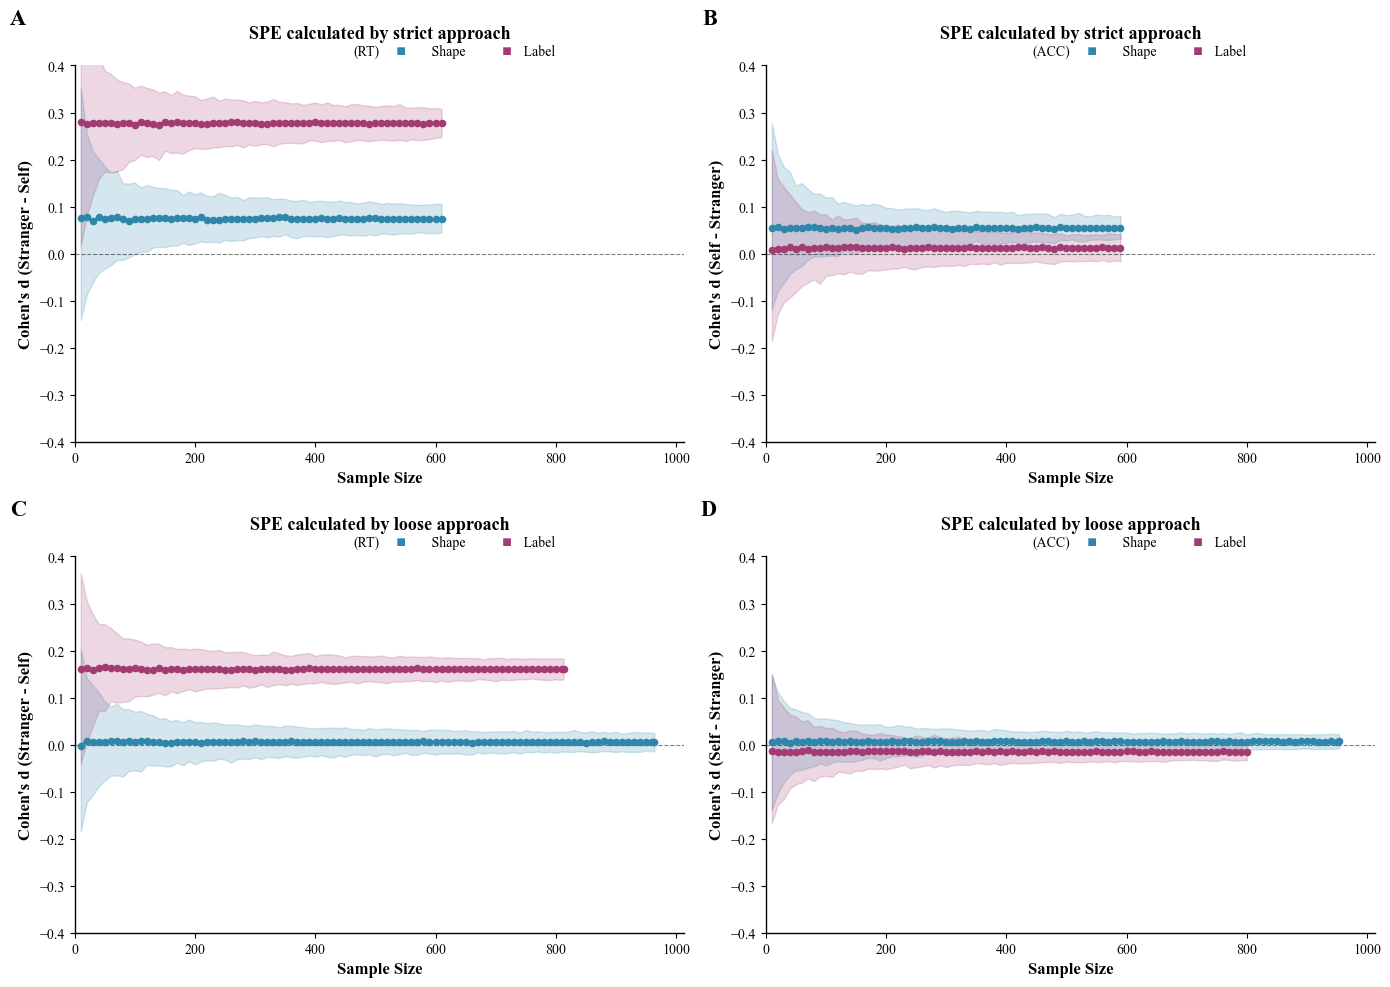


Saved: combined_figures_v4.3.png


In [7]:
# Create combined figure
def create_combined_figure(strict_rt, strict_acc, loose_rt, loose_acc):
    """
    Create 2x2 figure:
    - Row 1: Strict approach (Aligned) - RT and ACC
    - Row 2: Loose approach (Max) - RT and ACC
    """
    shape_color = '#2E86AB'
    label_color = '#A23B72'
    
    # Find max sample size for x-axis
    all_max_n = 0
    for data in [strict_rt, strict_acc, loose_rt, loose_acc]:
        if not data.empty:
            all_max_n = max(all_max_n, data['SampleSize'].max())
    
    # Fixed axis limits
    x_min, x_max = 0, all_max_n + 50
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'Strict'),
        (axes[0, 1], strict_acc, 'ACC', 'Strict'),
        (axes[1, 0], loose_rt, 'RT', 'Loose'),
        (axes[1, 1], loose_acc, 'ACC', 'Loose'),
    ]
    
    for ax, data, measure, approach in plot_configs:
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            continue
        
        # Plot Shape and Label
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            color = shape_color if identity == 'Shape' else label_color
            ax.plot(subset['SampleSize'], subset['Mean_d'], color=color, linewidth=2)
            ax.fill_between(subset['SampleSize'], subset['CI_lower'], subset['CI_upper'], color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], color=color, s=20, zorder=5)
        
        # Zero line
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Set axes
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Labels
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if approach == 'Strict' else 'C') if measure == 'RT' else ('B' if approach == 'Strict' else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        
        # Title
        title_text = f"SPE calculated by {approach.lower()} approach"
        ax.set_title(title_text, fontsize=13, fontweight='bold', family='Times New Roman', pad=20)
        
        # Subtitle with measure and legend
        ax.text(0.5, 1.02, f'({measure})', transform=ax.transAxes, fontsize=10, ha='right', va='bottom')
        ax.text(0.52, 1.02, ' ■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=shape_color, fontweight='bold')
        ax.text(0.58, 1.02, ' Shape  ', transform=ax.transAxes, fontsize=10, ha='left', va='bottom')
        ax.text(0.70, 1.02, '■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=label_color, fontweight='bold')
        ax.text(0.73, 1.02, ' Label', transform=ax.transAxes, fontsize=10, ha='left', va='bottom')
        
        # Subplot label
        ax.text(-0.08, 1.15, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        
        # APA style
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    
    # Save
    filename = 'combined_figures_v4.3.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"\nSaved: {filename}")

# Generate figure
print("\n" + "=" * 80)
print("GENERATING COMBINED FIGURE")
print("=" * 80)

create_combined_figure(
    strict_results['rt'],
    strict_results['acc'],
    loose_results['rt'],
    loose_results['acc']
)

In [8]:
# Save results
print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

# Save CSV files
strict_results['rt'].to_csv(output_path / 'bootstrap_rt_strict_v4.3.csv', index=False)
strict_results['acc'].to_csv(output_path / 'bootstrap_acc_strict_v4.3.csv', index=False)
loose_results['rt'].to_csv(output_path / 'bootstrap_rt_loose_v4.3.csv', index=False)
loose_results['acc'].to_csv(output_path / 'bootstrap_acc_loose_v4.3.csv', index=False)

print("\nFiles saved:")
print("  - combined_figures_v4.3.png")
print("  - bootstrap_rt_strict_v4.3.csv")
print("  - bootstrap_acc_strict_v4.3.csv")
print("  - bootstrap_rt_loose_v4.3.csv")
print("  - bootstrap_acc_loose_v4.3.csv")


SAVING RESULTS

Files saved:
  - combined_figures_v4.3.png
  - bootstrap_rt_strict_v4.3.csv
  - bootstrap_acc_strict_v4.3.csv
  - bootstrap_rt_loose_v4.3.csv
  - bootstrap_acc_loose_v4.3.csv


In [9]:
# Print summary
print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

for approach, results in [('Strict (Aligned)', strict_results), ('Loose (Max)', loose_results)]:
    print(f"\n{approach}:")
    for measure in ['rt', 'acc']:
        data = results[measure]
        if not data.empty:
            print(f"  {measure.upper()}:")
            for identity in ['Shape', 'Label']:
                subset = data[data['Identity'] == identity]
                if not subset.empty:
                    max_n = subset['SampleSize'].max()
                    final = subset[subset['SampleSize'] == max_n].iloc[0]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: N = {max_n}, d = {final['Mean_d']:.3f}, CI [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Sig: {sig}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


ANALYSIS SUMMARY

Strict (Aligned):
  RT:
    Shape: N = 610, d = 0.074, CI [0.045, 0.106], Sig: Yes
    Label: N = 610, d = 0.278, CI [0.248, 0.308], Sig: Yes
  ACC:
    Shape: N = 590, d = 0.055, CI [0.032, 0.080], Sig: Yes
    Label: N = 590, d = 0.011, CI [-0.017, 0.041], Sig: No

Loose (Max):
  RT:
    Shape: N = 964, d = 0.004, CI [-0.015, 0.025], Sig: No
    Label: N = 813, d = 0.161, CI [0.140, 0.183], Sig: Yes
  ACC:
    Shape: N = 954, d = 0.007, CI [-0.008, 0.022], Sig: No
    Label: N = 800, d = -0.016, CI [-0.033, 0.001], Sig: No

ANALYSIS COMPLETE!


## Summary

### Definitions
- **Strict approach**: Aligned version - Shape和Label样本量对齐到最小值
- **Loose approach**: Max version - 各自取最大样本量

### Output
- `combined_figures_v4.3.png`: 2x2 combined figure
- 4 CSV files with bootstrap results

### Figure Layout
```
┌─────────────────────────────────────────────────────────┐
│  A. SPE calculated by strict approach (RT)              │
│                                                         │
│     B. SPE calculated by strict approach (ACC)          │
├─────────────────────────────────────────────────────────┤
│  C. SPE calculated by loose approach (RT)               │
│                                                         │
│     D. SPE calculated by loose approach (ACC)           │
└─────────────────────────────────────────────────────────┘
```